In [4]:
import torch
import numpy as np
import pandas as pd


In [5]:
import os
import cv2  # для загрузки изображений
import seaborn as sns
# Путь к папке с изображениями и .txt файлами
data_folder = './images'

# Списки для хранения данных
X = []
Y = []

# Проходим по всем файлам в папке
for filename in os.listdir(data_folder):
    if filename.endswith('.jpg') or filename.endswith('.png'):
        # Полный путь к изображению
        img_path = os.path.join(data_folder, filename)
        
        # Полный путь к соответствующему .txt файлу
        txt_filename = os.path.splitext(filename)[0] + '.txt'
        txt_path = os.path.join(data_folder, txt_filename)
        
        # Загрузка изображения
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        X.append(img.reshape(1,64,64))
        
        # Загрузка разметки
        if os.path.exists(txt_path):
            with open(txt_path, 'r') as f:
                label = f.read().strip()
                print(len(label.split()))
                Y.append(np.array(label.split()).reshape(1,64,64))
        else:
            print(f"Warning: разметка для {filename} не найдена.")
            Y.append(None)

# Приводим к numpy массиву
X = torch.Tensor(np.array(X).astype("float"))
Y = torch.Tensor(np.array(Y).astype("float"))

print(f"Создан датасет: X shape = {X.shape}, Y shape = {Y.shape}")


4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096
4096


In [6]:
X[0]

tensor([[[174., 160., 172.,  ..., 182., 223., 244.],
         [213., 226., 184.,  ..., 223., 217., 154.],
         [163., 202., 194.,  ..., 165., 127., 135.],
         ...,
         [137., 131., 122.,  ...,  99., 100., 114.],
         [136., 129., 118.,  ...,  85.,  89., 112.],
         [132., 125., 117.,  ...,  73.,  91., 109.]]])

In [7]:
s = cv2.imread("E:/My projects/ML Yandex HandBook/dart/images/1.png",cv2.IMREAD_GRAYSCALE)

In [8]:
Y[0][0]

tensor([[ 324.8164,  364.2344,  353.4336,  ...,  326.7383,  229.5977,
           33.4297],
        [ 339.8203,  287.3828,  229.9023,  ...,  166.5195,   54.4961,
         -134.2344],
        [ 289.4023,  188.0352,  113.9648,  ...,   55.8477,  -46.6094,
         -207.7773],
        ...,
        [ 227.9492,  131.4688,   66.8242,  ...,   20.4141,  -33.4648,
         -130.6914],
        [ 158.0312,   54.9531,   -8.4961,  ...,  -30.8555,  -69.5234,
         -135.5664],
        [  23.8477,  -83.9180, -141.9883,  ..., -111.9961, -124.3828,
         -131.6523]])

In [317]:
model = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1, out_channels=1, kernel_size = 3, padding=1),
    torch.nn.Conv2d(in_channels=1, out_channels=1,kernel_size = 3, padding=1),
    torch.nn.Conv2d(in_channels=1, out_channels=1,kernel_size = 3,padding=1),
)
model[2].weight.requires_grad = False
model[2].weight.copy_(torch.Tensor(np.array([-1.0,-0.5,0.0,-0.5,0.5,0.5,0.0,0.5,1.0]).reshape(3,3)))
model[0].weight.requires_grad = False
model[0].weight.copy_(torch.Tensor(np.array([0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625]).reshape(3,3)))



Parameter containing:
tensor([[[[0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625]]]])

In [318]:
from torch.utils.data import DataLoader, Dataset

class MyDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.Y[index]
    
data = MyDataset(X,Y)

In [342]:
dataloader =  DataLoader(data, batch_size=32, shuffle=True)
optim = torch.optim.Adam(model.parameters(),lr = 1e-8)
loss_fn = torch.nn.MSELoss()


In [344]:
for epoch in range(100):
    model.train()
    loss_all= 0
    for x, y in dataloader:
        optim.zero_grad()

        output = model(x)
        
        loss = loss_fn(output,y)

        loss.backward()

        optim.step()
    
    print(loss.item())

1.3532228115842315e-10
1.3058801262566533e-10
6.590312323639935e-11
9.450650678699546e-11
9.884909557555943e-11
1.244574998615633e-10
1.2753530176379257e-10
1.8917713229260613e-10
1.401230104169926e-10
7.533033918871723e-11
8.325833772415692e-11
1.2001055704757846e-10
1.000571847598053e-10
1.7317737521782561e-10
1.395128179648708e-10
1.3951496902198102e-10
8.801809281422379e-11
9.639254672233477e-11
7.746357721938324e-11
7.975227422907238e-11
7.093461235063714e-11
9.721386889927075e-11
6.687307652075702e-11
7.959126413492612e-11
9.370303144518033e-11
8.280521407444397e-11
7.334419183102625e-11
9.137685746951618e-11
9.441444154267842e-11
8.712259386145504e-11
9.709903714405499e-11
6.884946779361911e-11
8.152216401935419e-11
9.288599056578306e-11
8.789038941081628e-11
1.1269730981755544e-10
7.73903302553336e-11
7.632232346121981e-11
8.72169836352299e-11
1.0612649647967487e-10
7.766210591286793e-11
9.892313357351412e-11
8.723489985928978e-11
9.578704496249202e-11
8.229961157013577e-11
7.9

<Axes: >

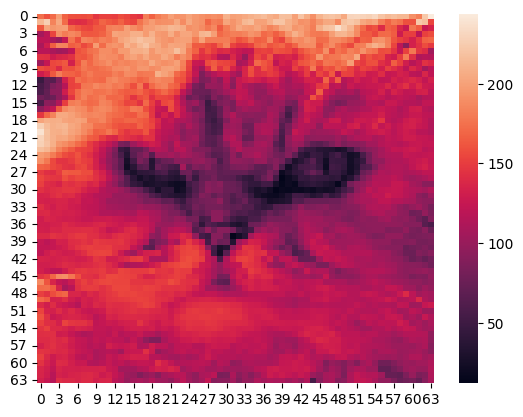

In [345]:
sns.heatmap(X[0].reshape(64,64))

<Axes: >

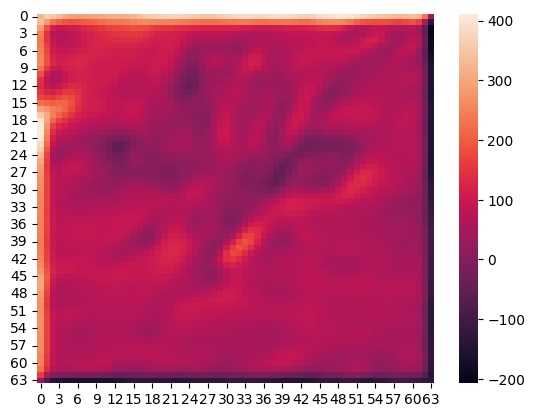

In [346]:
sns.heatmap(Y[0].reshape(64,64))

<Axes: >

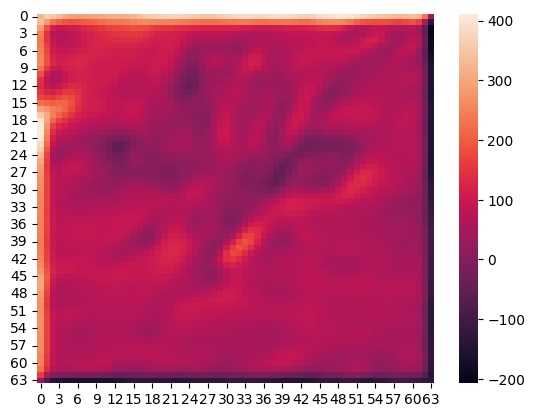

In [347]:
sns.heatmap(model(X[0]).detach().numpy().reshape(64,64))

In [350]:
model[1].weight.detach().numpy().squeeze(1).reshape(1,9)[0].tolist()

[0.1250002384185791,
 0.24999962747097015,
 0.12500017881393433,
 0.24999959766864777,
 0.5000006556510925,
 0.24999967217445374,
 0.12500019371509552,
 0.24999964237213135,
 0.1250002086162567]